In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
!pip install ultralytics

In [ ]:
import os
import cv2
import pandas as pd
import numpy as np
from tqdm import tqdm
from ultralytics import YOLO

In [ ]:
train_csv = "/kaggle/input/datasets/alaagastien/cliniscan2/train.csv"
meta_csv = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train_meta.csv"

df = pd.read_csv(train_csv)
meta = pd.read_csv(meta_csv)

print("Train rows:", len(df))
print("Meta rows:", len(meta))

Train rows: 67914
Meta rows: 15000


In [ ]:
df = df[df["class_id"] != 14]

print("After removing No finding:", len(df))

After removing No finding: 36096


In [ ]:
df = df.dropna(subset=["x_min","y_min","x_max","y_max"])

print("Valid annotations:", len(df))

Valid annotations: 36096


In [ ]:
size_dict = {}

for _, row in meta.iterrows():
    size_dict[row["image_id"]] = (row["dim0"], row["dim1"])

In [ ]:
base = "/kaggle/working/dataset"

img_dir = f"{base}/images/train"
lbl_dir = f"{base}/labels/train"

os.makedirs(img_dir, exist_ok=True)
os.makedirs(lbl_dir, exist_ok=True)

In [ ]:
for img_id, group in tqdm(df.groupby("image_id")):

    h, w = size_dict[img_id]

    label_path = os.path.join(lbl_dir, img_id + ".txt")

    with open(label_path, "w") as f:

        for _, row in group.iterrows():

            x_min = row["x_min"]
            y_min = row["y_min"]
            x_max = row["x_max"]
            y_max = row["y_max"]

            xc = ((x_min + x_max) / 2) / w
            yc = ((y_min + y_max) / 2) / h

            bw = (x_max - x_min) / w
            bh = (y_max - y_min) / h

            class_id = int(row["class_id"])

            f.write(f"{class_id} {xc} {yc} {bw} {bh}\n")

100%|██████████| 4394/4394 [00:03<00:00, 1424.51it/s]


In [ ]:
src_img_dir = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train"

for img in tqdm(os.listdir(src_img_dir)):
    
    src = os.path.join(src_img_dir, img)
    dst = os.path.join(img_dir, img)

    if not os.path.exists(dst):
        os.system(f"cp {src} {dst}")

100%|██████████| 15000/15000 [03:16<00:00, 76.33it/s]


In [ ]:
images = set([os.path.splitext(f)[0] for f in os.listdir(img_dir)])
labels = set([os.path.splitext(f)[0] for f in os.listdir(lbl_dir)])

missing = images - labels

for img in missing:
    open(os.path.join(lbl_dir, img + ".txt"), "w").close()

print("Empty labels created:", len(missing))

Empty labels created: 10606


In [ ]:
print("Images:", len(os.listdir(img_dir)))
print("Labels:", len(os.listdir(lbl_dir)))

Images: 15000
Labels: 15000


In [ ]:
data_yaml = """
train: /kaggle/working/dataset/images/train
val: /kaggle/working/dataset/images/train

nc: 14

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

with open("/kaggle/working/data.yaml","w") as f:
    f.write(data_yaml)

In [ ]:
model.predict(
    source="/kaggle/input/datasets/alaagastien/cliniscan2/archive/test",
    save=True,
    conf=0.25
)

In [ ]:
model = YOLO("yolo11s.pt")

model.train(
    data="/kaggle/working/data.yaml",
    epochs=25,
    imgsz=1024,
    batch=8
)

In [ ]:
!pip install ultralytics

In [ ]:
from ultralytics import YOLO

# Load your trained weights from Milestone 2
# Note: Double check if your path is 'best.pt' or 'last.pt'
model = YOLO('/kaggle/working/runs/detect/train/weights/best.pt')

In [ ]:
from ultralytics import YOLO

# 1. Load the best weights you've trained
model = YOLO('/kaggle/input/notebook7f8f594ad4/yolo11s.pt')

# 2. Run the prediction on your test images
results = model.predict(
    source="/kaggle/input/cliniscan2/archive/test", 
    save=True,      # This saves the images with bounding boxes
    conf=0.25      # Only show detections the model is >25% sure about
)

In [ ]:
import os
# This searches your entire working directory for any .pt files
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.endswith(".pt"):
            print(os.path.join(root, file))

In [ ]:
import os

# This looks for any file ending in '.pt' in your working directory
for root, dirs, files in os.walk('/kaggle/working'):
    for file in files:
        if file.endswith('.pt'):
            print(f"Found your model at: {os.path.join(root, file)}")

In [ ]:
import os
print("--- Checking for Weights ---")
for root, dirs, files in os.walk('/kaggle'):
    for file in files:
        if file.endswith('.pt'):
            print(f"FOUND IT: {os.path.join(root, file)}")

In [ ]:
# 1. Install the library
!pip install ultralytics -q

# 2. Load the model from your specific Output path
from ultralytics import YOLO
# Based on your image 7e312e60, the path to your best weights is:
model = YOLO('/kaggle/working/yolo11s.pt')

In [ ]:
results = model.predict(
    source="/kaggle/input/cliniscan2/archive/test", 
    save=True, 
    conf=0.25
)

In [ ]:
import os
from ultralytics import YOLO

# 1. Check if the test folder exists before running
test_path = "/kaggle/input/cliniscan2/archive/test"

if os.path.exists(test_path):
    print("✅ Test folder found! Starting prediction...")
    
    # 2. Load the model from your current working directory
    model = YOLO('/kaggle/working/yolo11s.pt')

    # 3. Run the prediction with the CORRECT absolute path
    results = model.predict(
        source=test_path, 
        save=True, 
        conf=0.25
    )
    print("🚀 Done! Check the 'predict' folder in your Output.")
else:
    print("❌ Error: Path not found. Run the code below to see the real path.")
    !ls /kaggle/input/cliniscan2/archive/

In [ ]:
!pip install torch torchvision timm

In [ ]:
import os
import pandas as pd
import numpy as np
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [ ]:
train_csv = "/kaggle/input/datasets/alaagastien/cliniscan2/train.csv"
img_dir = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train"
df = pd.read_csv(train_csv)

In [ ]:
df = df[df["class_id"] != 14]

In [ ]:
# Create Image  Single Label Mapping
df = df.sort_values("image_id")

df_single = df.groupby("image_id").first().reset_index()

print("Total images:", len(df_single))

In [ ]:
class XrayDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img_path = os.path.join(self.img_dir, row["image_id"] + ".png")
        image = Image.open(img_path).convert("RGB")
        
        label = int(row["class_id"])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [ ]:
#Transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [ ]:
dataset = XrayDataset(df_single, img_dir, transform)

train_loader = DataLoader(dataset, batch_size=16, shuffle=True)

In [ ]:
model = models.resnet50(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, 14)

model = model.cuda()

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
epochs = 5

for epoch in range(epochs):
    
    model.train()
    total_loss = 0
    
    for images, labels in train_loader:
        
        images = images.cuda()
        labels = labels.cuda()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import torch.nn.functional as F

In [ ]:
model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    
    for images, labels in train_loader:
        
        images = images.cuda()
        labels = labels.cuda()
        
        outputs = model(images)
        
        probs = F.softmax(outputs, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

In [ ]:
accuracy = accuracy_score(all_labels, all_preds)
print("Accuracy:", accuracy)

In [ ]:
f1 = f1_score(all_labels, all_preds, average='macro')
print("F1 Score:", f1)


In [ ]:
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
print("AUC:", auc)

In [ ]:
torch.save(model.state_dict(), "/kaggle/working/cliniscan_classification_model.pth")

print("Model saved successfully")

In [ ]:
import os

print(os.listdir("/kaggle/working"))

In [ ]:
from IPython.display import FileLink

FileLink("/kaggle/working/cliniscan_classification_model.pth")

In [ ]:
class_names = {
 0: "Aortic enlargement",
 1: "Atelectasis",
 2: "Calcification",
 3: "Cardiomegaly",
 4: "Consolidation",
 5: "ILD",
 6: "Infiltration",
 7: "Lung Opacity",
 8: "Nodule/Mass",
 9: "Other lesion",
 10: "Pleural effusion",
 11: "Pleural thickening",
 12: "Pneumothorax",
 13: "Pulmonary fibrosis"
}

import json

with open("/kaggle/working/class_names.json", "w") as f:
    json.dump(class_names, f)

In [ ]:
FileLink("/kaggle/working/class_names.json")

In [ ]:
!pip install ultralytics albumentations timm -q

In [ ]:
import os, json, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score,
                             roc_auc_score, classification_report)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from ultralytics import YOLO

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
TRAIN_CSV = "/kaggle/input/datasets/alaagastien/cliniscan2/train.csv"
META_CSV  = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train_meta.csv"
IMG_DIR   = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train"
WORK_DIR  = "/kaggle/working"

CLASS_NAMES = {
    0: "Aortic enlargement",  1: "Atelectasis",       2: "Calcification",
    3: "Cardiomegaly",        4: "Consolidation",     5: "ILD",
    6: "Infiltration",        7: "Lung Opacity",      8: "Nodule/Mass",
    9: "Other lesion",       10: "Pleural effusion", 11: "Pleural thickening",
   12: "Pneumothorax",       13: "Pulmonary fibrosis"
}
NUM_CLASSES = 14

df   = pd.read_csv(TRAIN_CSV)
meta = pd.read_csv(META_CSV)

# Remove 'No finding' and drop rows missing bbox
df = df[df["class_id"] != 14]
df = df.dropna(subset=["x_min", "y_min", "x_max", "y_max"])

# One primary label per image
df_single = df.sort_values("image_id").groupby("image_id").first().reset_index()

# Stratified split
train_df, val_df = train_test_split(
    df_single, test_size=0.2, stratify=df_single["class_id"], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f"Train: {len(train_df)}  |  Val: {len(val_df)}")
print("Class distribution (train):")
print(train_df["class_id"].value_counts().sort_index())

Train: 3515  |  Val: 879
Class distribution (train):
class_id
0     903
1      20
2      74
3     712
4      43
5      94
6     102
7     195
8     185
9     189
10    192
11    379
12     23
13    404
Name: count, dtype: int64


In [ ]:
IMGSIZE = 224

train_transforms = A.Compose([
    A.Resize(IMGSIZE, IMGSIZE),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(brightness_limit=0.2,
                               contrast_limit=0.2, p=0.4),
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.2),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Resize(IMGSIZE, IMGSIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

print("Augmentation pipelines ready.")

Augmentation pipelines ready.


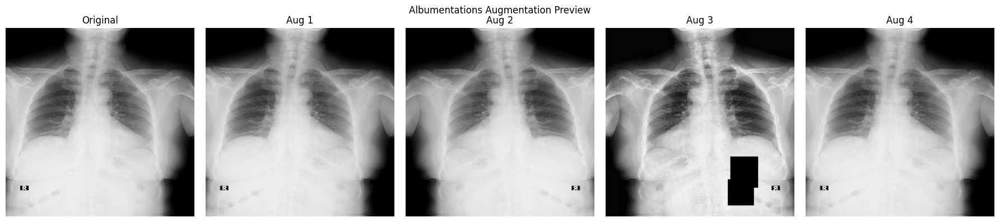

In [ ]:
# Preview augmentations on one training sample
sample_img_id = train_df.iloc[0]["image_id"]
sample_img    = np.array(Image.open(
    os.path.join(IMG_DIR, sample_img_id + '.png')
).convert('RGB'))

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
axes[0].imshow(sample_img); axes[0].set_title('Original'); axes[0].axis('off')

for i in range(1, 5):
    aug = A.Compose(train_transforms.transforms[:-2])(image=sample_img)['image']
    axes[i].imshow(aug); axes[i].set_title(f'Aug {i}'); axes[i].axis('off')

plt.suptitle('Albumentations Augmentation Preview', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'augmentation_preview.png'), dpi=120)
plt.show()

In [ ]:
class XrayDataset(Dataset):
    def __init__(self, df, img_dir, transforms=None):
        self.df         = df
        self.img_dir    = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = os.path.join(self.img_dir, row["image_id"] + ".png")
        image = np.array(Image.open(path).convert("RGB"))
        label = int(row["class_id"])
        if self.transforms:
            image = self.transforms(image=image)["image"]
        return image, label


BATCH_SIZE = 32

train_dataset = XrayDataset(train_df, IMG_DIR, train_transforms)
val_dataset   = XrayDataset(val_df,   IMG_DIR, val_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}")

Train batches: 110  |  Val batches: 28


In [ ]:
def build_model(num_classes=NUM_CLASSES, dropout=0.4):
    model = models.resnet50(pretrained=True)
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(dropout),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(dropout / 2),
        nn.Linear(256, num_classes)
    )
    return model

model = build_model().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params:,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 173MB/s] 


Total parameters: 24,036,174


In [ ]:
# ── Training & evaluation helpers ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (model(images).argmax(1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        probs   = F.softmax(outputs, dim=1)
        preds   = probs.argmax(1)
        correct += (preds == labels).sum().item()
        total   += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')
    return total_loss / total, correct / total, f1, auc, all_preds, all_labels, all_probs

print("Helpers ready.")

Helpers ready.


In [ ]:
# ── Phase 1: Freeze backbone ───────────────────────────────────────────────────
PHASE1_EPOCHS = 5
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

for name, param in model.named_parameters():
    param.requires_grad = ('fc' in name)

optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3
)

history = {k: [] for k in ['train_loss', 'val_loss', 'val_acc', 'val_f1', 'val_auc']}

print("=== Phase 1: Backbone frozen, training head only ===")
for epoch in range(PHASE1_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p1)
    vl_loss, vl_acc, vl_f1, vl_auc, *_ = evaluate(model, val_loader, criterion)
    for k, v in zip(['train_loss','val_loss','val_acc','val_f1','val_auc'],
                    [tr_loss, vl_loss, vl_acc, vl_f1, vl_auc]):
        history[k].append(v)
    print(f"  Ep {epoch+1}/{PHASE1_EPOCHS} | "
          f"TrLoss={tr_loss:.4f} | VlLoss={vl_loss:.4f} | "
          f"Acc={vl_acc:.4f} | F1={vl_f1:.4f} | AUC={vl_auc:.4f}")

=== Phase 1: Backbone frozen, training head only ===
  Ep 1/5 | TrLoss=2.3281 | VlLoss=2.2291 | Acc=0.2810 | F1=0.0496 | AUC=0.6376
  Ep 2/5 | TrLoss=2.2666 | VlLoss=2.2272 | Acc=0.2594 | F1=0.0321 | AUC=0.6465
  Ep 3/5 | TrLoss=2.2552 | VlLoss=2.1948 | Acc=0.2821 | F1=0.0514 | AUC=0.6647
  Ep 4/5 | TrLoss=2.2441 | VlLoss=2.1973 | Acc=0.2821 | F1=0.0527 | AUC=0.6624
  Ep 5/5 | TrLoss=2.2526 | VlLoss=2.1845 | Acc=0.2935 | F1=0.0561 | AUC=0.6710


In [ ]:
# ── Phase 2: Unfreeze all + fine-tune ─────────────────────────────────────────
PHASE2_EPOCHS = 10

for param in model.parameters():
    param.requires_grad = True

optimizer_p2 = torch.optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)
scheduler    = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS, eta_min=1e-7
)

best_val_f1    = 0.0
best_cls_path  = os.path.join(WORK_DIR, 'cliniscan_best_cls_m3.pth')

print("=== Phase 2: Full fine-tuning ===")
for epoch in range(PHASE2_EPOCHS):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer_p2)
    vl_loss, vl_acc, vl_f1, vl_auc, *_ = evaluate(model, val_loader, criterion)
    scheduler.step()

    for k, v in zip(['train_loss','val_loss','val_acc','val_f1','val_auc'],
                    [tr_loss, vl_loss, vl_acc, vl_f1, vl_auc]):
        history[k].append(v)

    saved = ''
    if vl_f1 > best_val_f1:
        best_val_f1 = vl_f1
        torch.save(model.state_dict(), best_cls_path)
        saved = ' ← BEST SAVED'

    print(f"  Ep {epoch+1}/{PHASE2_EPOCHS} | "
          f"TrLoss={tr_loss:.4f} | VlLoss={vl_loss:.4f} | "
          f"Acc={vl_acc:.4f} | F1={vl_f1:.4f} | AUC={vl_auc:.4f}{saved}")

print(f"\nBest Val F1 (macro): {best_val_f1:.4f}")

=== Phase 2: Full fine-tuning ===
  Ep 1/10 | TrLoss=2.2179 | VlLoss=2.1610 | Acc=0.2992 | F1=0.0597 | AUC=0.6811 ← BEST SAVED
  Ep 2/10 | TrLoss=2.2014 | VlLoss=2.1448 | Acc=0.2992 | F1=0.0605 | AUC=0.6893 ← BEST SAVED
  Ep 3/10 | TrLoss=2.1774 | VlLoss=2.1334 | Acc=0.2992 | F1=0.0630 | AUC=0.6948 ← BEST SAVED
  Ep 4/10 | TrLoss=2.1611 | VlLoss=2.1226 | Acc=0.2981 | F1=0.0641 | AUC=0.7077 ← BEST SAVED
  Ep 5/10 | TrLoss=2.1482 | VlLoss=2.1160 | Acc=0.3003 | F1=0.0682 | AUC=0.7156 ← BEST SAVED
  Ep 6/10 | TrLoss=2.1374 | VlLoss=2.1085 | Acc=0.3083 | F1=0.0689 | AUC=0.7218 ← BEST SAVED
  Ep 7/10 | TrLoss=2.1256 | VlLoss=2.1095 | Acc=0.3083 | F1=0.0706 | AUC=0.7199 ← BEST SAVED
  Ep 8/10 | TrLoss=2.1241 | VlLoss=2.1099 | Acc=0.2992 | F1=0.0677 | AUC=0.7165
  Ep 9/10 | TrLoss=2.1194 | VlLoss=2.1085 | Acc=0.3026 | F1=0.0682 | AUC=0.7180
  Ep 10/10 | TrLoss=2.1208 | VlLoss=2.1177 | Acc=0.2981 | F1=0.0678 | AUC=0.7115

Best Val F1 (macro): 0.0706


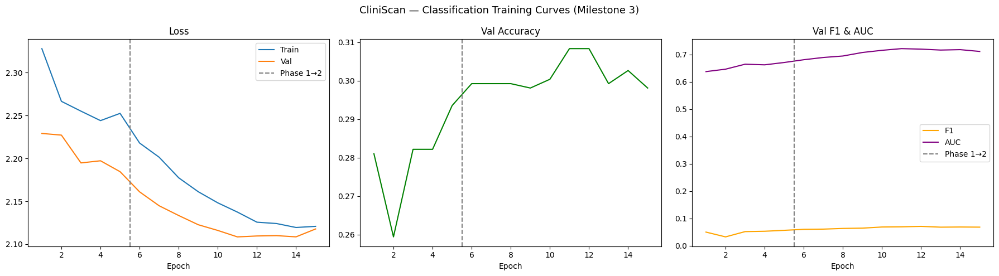

Saved: training_curves_m3.png


In [ ]:
total_epochs  = PHASE1_EPOCHS + PHASE2_EPOCHS
epochs_range  = range(1, total_epochs + 1)
phase_divider = PHASE1_EPOCHS + 0.5

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_range, history['train_loss'], label='Train')
axes[0].plot(epochs_range, history['val_loss'],   label='Val')
axes[0].axvline(phase_divider, color='gray', linestyle='--', label='Phase 1→2')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(epochs_range, history['val_acc'], color='green')
axes[1].axvline(phase_divider, color='gray', linestyle='--')
axes[1].set_title('Val Accuracy')

axes[2].plot(epochs_range, history['val_f1'],  label='F1',  color='orange')
axes[2].plot(epochs_range, history['val_auc'], label='AUC', color='purple')
axes[2].axvline(phase_divider, color='gray', linestyle='--', label='Phase 1→2')
axes[2].set_title('Val F1 & AUC'); axes[2].legend()

for ax in axes:
    ax.set_xlabel('Epoch')

plt.suptitle('CliniScan — Classification Training Curves (Milestone 3)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'training_curves_m3.png'), dpi=150)
plt.show()
print("Saved: training_curves_m3.png")

In [ ]:
# Load best checkpoint and run full val evaluation
model.load_state_dict(torch.load(best_cls_path, map_location=device))
_, val_acc, val_f1, val_auc, all_preds, all_labels, all_probs = \
    evaluate(model, val_loader, criterion)

print(f"Val Accuracy  : {val_acc:.4f}")
print(f"Val F1 (macro): {val_f1:.4f}")
print(f"Val AUC (OvR) : {val_auc:.4f}")

print("\nPer-Class Report:")
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0
))

Val Accuracy  : 0.3083
Val F1 (macro): 0.0706
Val AUC (OvR) : 0.7199

Per-Class Report:
                    precision    recall  f1-score   support

Aortic enlargement       0.34      0.85      0.49       226
       Atelectasis       0.00      0.00      0.00         5
     Calcification       0.00      0.00      0.00        18
      Cardiomegaly       0.42      0.11      0.18       178
     Consolidation       0.00      0.00      0.00        11
               ILD       0.00      0.00      0.00        23
      Infiltration       0.00      0.00      0.00        25
      Lung Opacity       0.00      0.00      0.00        49
       Nodule/Mass       0.00      0.00      0.00        47
      Other lesion       0.00      0.00      0.00        47
  Pleural effusion       0.00      0.00      0.00        48
Pleural thickening       0.00      0.00      0.00        95
      Pneumothorax       0.00      0.00      0.00         6
Pulmonary fibrosis       0.22      0.59      0.33       101

          

In [ ]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping."""

    def __init__(self, model, target_layer):
        self.model        = model
        self.gradients    = None
        self.activations  = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam     = F.interpolate(cam, size=input_tensor.shape[2:],
                                mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx


grad_cam = GradCAM(model, target_layer=model.layer4[-1])
print("Grad-CAM attached to ResNet50 layer4[-1]")

Grad-CAM attached to ResNet50 layer4[-1]


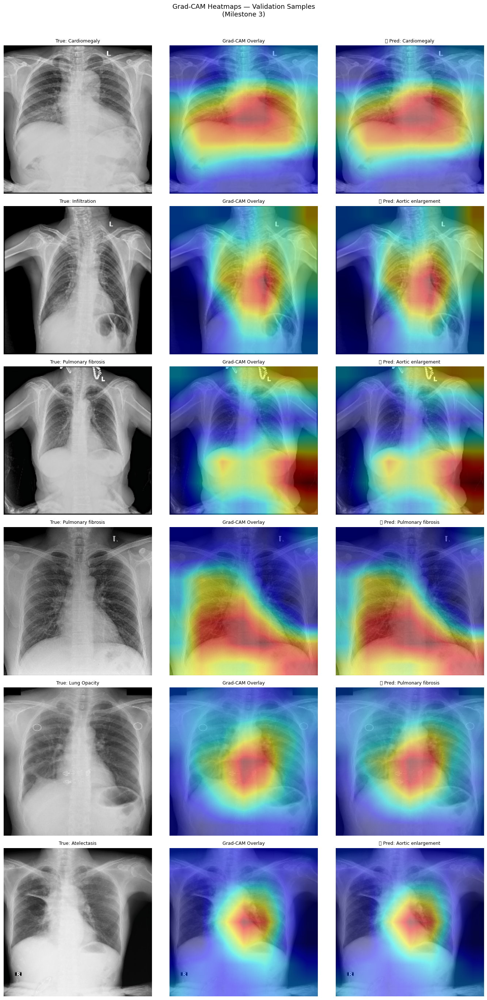

Saved: gradcam_heatmaps_m3.png


In [ ]:
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img, 0, 1)


NUM_GRADCAM = 6
sample_idx  = np.random.choice(len(val_dataset), NUM_GRADCAM, replace=False)

fig, axes = plt.subplots(NUM_GRADCAM, 3, figsize=(14, 4.5 * NUM_GRADCAM))
fig.suptitle('Grad-CAM Heatmaps — Validation Samples\n(Milestone 3)',
             fontsize=13, y=1.01)

for row, idx in enumerate(sample_idx):
    img_t, true_label = val_dataset[idx]
    inp   = img_t.unsqueeze(0).to(device)
    cam, pred_label = grad_cam.generate(inp)

    orig = denormalize(img_t)
    hm   = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    hm   = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
    blend = np.clip(0.55 * orig + 0.45 * hm, 0, 1)

    correct_mark = '✅' if pred_label == true_label else '❌'

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f"True: {CLASS_NAMES[true_label]}", fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(orig)
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Grad-CAM Overlay', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(blend)
    axes[row, 2].set_title(f"{correct_mark} Pred: {CLASS_NAMES[pred_label]}",
                           fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'gradcam_heatmaps_m3.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gradcam_heatmaps_m3.png")

In [ ]:
# ── Build YOLO dataset with proper train/val split ─────────────────────────────
BASE_YOLO = "/kaggle/working/yolo_dataset_m3"
for split in ['train', 'val']:
    os.makedirs(f"{BASE_YOLO}/images/{split}", exist_ok=True)
    os.makedirs(f"{BASE_YOLO}/labels/{split}", exist_ok=True)

size_dict = {row['image_id']: (row['dim0'], row['dim1'])
             for _, row in meta.iterrows()}

# Use all annotations (multi-label)
df_bbox = pd.read_csv(TRAIN_CSV)
df_bbox = df_bbox[df_bbox['class_id'] != 14]
df_bbox = df_bbox.dropna(subset=['x_min', 'y_min', 'x_max', 'y_max'])

train_ids = set(train_df['image_id'])
val_ids   = set(val_df['image_id'])

def write_yolo_split(ids, split):
    for img_id in tqdm(ids, desc=f'Writing {split}'):
        group = df_bbox[df_bbox['image_id'] == img_id]
        if img_id not in size_dict:
            continue
        h, w = size_dict[img_id]

        with open(f"{BASE_YOLO}/labels/{split}/{img_id}.txt", 'w') as f:
            for _, row in group.iterrows():
                xc = ((row.x_min + row.x_max) / 2) / w
                yc = ((row.y_min + row.y_max) / 2) / h
                bw = (row.x_max - row.x_min) / w
                bh = (row.y_max - row.y_min) / h
                f.write(f"{int(row.class_id)} {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}\n")

        src = os.path.join(IMG_DIR, img_id + '.png')
        dst = f"{BASE_YOLO}/images/{split}/{img_id}.png"
        if not os.path.exists(dst):
            os.system(f"cp {src} {dst}")

write_yolo_split(train_ids, 'train')
write_yolo_split(val_ids,   'val')
print("YOLO dataset written.")

Writing val: 100%|██████████| 879/879 [00:09<00:00, 95.64it/s] 

YOLO dataset written.


In [ ]:
# Write data YAML
yaml_content = f"""
train: {BASE_YOLO}/images/train
val:   {BASE_YOLO}/images/val

nc: {NUM_CLASSES}

names:
  0: Aortic enlargement
  1: Atelectasis
  2: Calcification
  3: Cardiomegaly
  4: Consolidation
  5: ILD
  6: Infiltration
  7: Lung Opacity
  8: Nodule/Mass
  9: Other lesion
  10: Pleural effusion
  11: Pleural thickening
  12: Pneumothorax
  13: Pulmonary fibrosis
"""

yaml_path = "/kaggle/working/data_m3.yaml"
with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print("data_m3.yaml written.")

data_m3.yaml written.


In [ ]:
# ── Train with tuned hyperparameters ──────────────────────────────────────────
yolo_model = YOLO('yolo11s.pt')

yolo_model.train(
    data          = yaml_path,
    epochs        = 30,
    imgsz         = 640,
    batch         = 16,
    lr0           = 0.005,
    lrf           = 0.01,
    momentum      = 0.937,
    weight_decay  = 5e-4,
    warmup_epochs = 3,
    cos_lr        = True,
    mosaic        = 1.0,
    mixup         = 0.15,
    degrees       = 10.0,
    hsv_h         = 0.015,
    hsv_s         = 0.3,
    hsv_v         = 0.3,
    flipud        = 0.1,
    patience      = 10,
    project       = WORK_DIR,
    name          = 'yolo_m3',
    exist_ok      = True,
    device        = 0 if torch.cuda.is_available() else 'cpu'
)

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/data_m3.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.3, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo_m3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79ec4064dd60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.0

In [ ]:
best_yolo_path = os.path.join(WORK_DIR, 'yolo_m3/weights/best.pt')
yolo_best = YOLO(best_yolo_path)

metrics = yolo_best.val(data=yaml_path, imgsz=640)

print(f"mAP@0.50     : {metrics.box.map50:.4f}")
print(f"mAP@0.50:0.95: {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,418,218 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3002.0±799.5 MB/s, size: 451.4 KB)
val: Scanning /kaggle/working/yolo_dataset_m3/labels/val.cache... 879 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 879/879 307.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 3.1it/s 17.8s0.3s
                   all        879       7227      0.422      0.352      0.342       0.17
    Aortic enlargement        597       1415      0.652      0.648      0.694      0.424
           Atelectasis         35         49      0.487      0.184      0.232      0.113
         Calcification         97        204      0.235      0.186      0.132     0.0551
          Cardiomegaly        445       1040       0.75      0.537      0.675       0.44
         Consolidation    

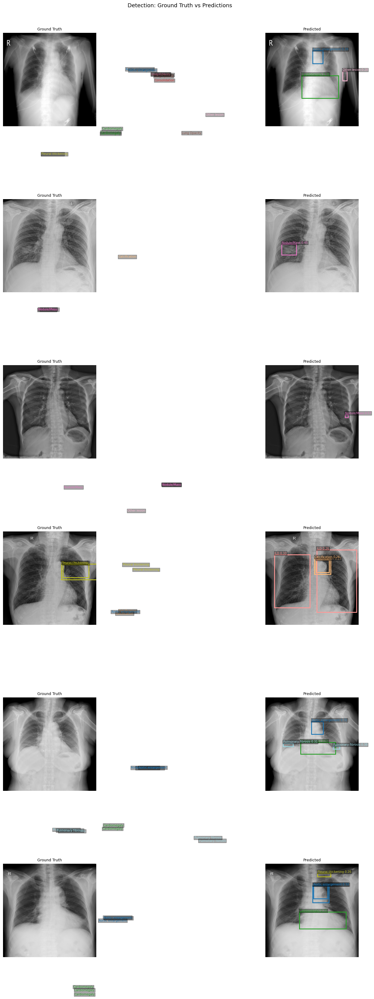

Saved: bbox_visualization_m3.png


In [ ]:
COLORS = plt.cm.get_cmap('tab20', NUM_CLASSES)


def draw_boxes(ax, boxes, labels, title, scores=None):
    for i, (box, lbl) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = box
        color = COLORS(int(lbl))[:3]
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        text = CLASS_NAMES[int(lbl)]
        if scores is not None:
            text += f" {scores[i]:.2f}"
        ax.text(x1, y1 - 4, text, color=color, fontsize=7,
                bbox=dict(facecolor='black', alpha=0.35, pad=1))
    ax.set_title(title, fontsize=9)
    ax.axis('off')


sample_val_ids = list(val_ids)[:6]
fig, axes = plt.subplots(len(sample_val_ids), 2,
                         figsize=(14, 5.5 * len(sample_val_ids)))
fig.suptitle('Detection: Ground Truth vs Predictions ',
             fontsize=13, y=1.01)

for row_i, img_id in enumerate(sample_val_ids):
    img_path = os.path.join(IMG_DIR, img_id + '.png')
    img      = np.array(Image.open(img_path).convert('RGB'))

    # Ground truth
    gt       = df_bbox[df_bbox['image_id'] == img_id]
    gt_boxes = gt[['x_min','y_min','x_max','y_max']].values
    gt_lbls  = gt['class_id'].values

    axes[row_i, 0].imshow(img)
    draw_boxes(axes[row_i, 0], gt_boxes, gt_lbls, 'Ground Truth')

    # Predictions
    res = yolo_best.predict(source=img_path, conf=0.25, verbose=False)[0]
    if len(res.boxes):
        pr_boxes  = res.boxes.xyxy.cpu().numpy()
        pr_labels = res.boxes.cls.cpu().numpy()
        pr_scores = res.boxes.conf.cpu().numpy()
        axes[row_i, 1].imshow(img)
        draw_boxes(axes[row_i, 1], pr_boxes, pr_labels, 'Predicted', pr_scores)
    else:
        axes[row_i, 1].imshow(img)
        axes[row_i, 1].set_title('Predicted (no detections)', fontsize=9)
        axes[row_i, 1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'bbox_visualization_m3.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bbox_visualization_m3.png")

In [ ]:
print("=" * 65)
print("     CliniScan — Milestone 3 Results Summary")
print("=" * 65)

print("\n[Classification — ResNet50 + Staged Fine-Tuning]")
print(f"  Val Accuracy  : {val_acc:.4f}")
print(f"  Val F1 (macro): {val_f1:.4f}")
print(f"  Val AUC (OvR) : {val_auc:.4f}")

print("\n[Detection — YOLOv11s + Tuned Hyperparameters]")
print(f"  mAP@0.50     : {metrics.box.map50:.4f}")
print(f"  mAP@0.50:0.95: {metrics.box.map:.4f}")
print(f"  Precision    : {metrics.box.mp:.4f}")
print(f"  Recall       : {metrics.box.mr:.4f}")

print("\n[Key Improvements Over Milestone 2]")
improvements = [
    "Albumentations pipeline: CLAHE, GaussNoise, CoarseDropout, jitter",
    "Stratified 80/20 train-val split (was train==val before)",
    "Staged transfer learning: freeze→unfreeze backbone",
    "Label smoothing (0.1) + AdamW + cosine LR schedule",
    "Best-model checkpoint saved on Val F1 (not just last epoch)",
    "Grad-CAM heatmaps for interpretability",
    "YOLO: mosaic, mixup, cos_lr, warmup, early stopping",
    "Refined GT vs Predicted bounding-box side-by-side visualization",
    "Per-class classification report",
]
for imp in improvements:
    print(f"  ✅ {imp}")

print("\n[Saved Artifacts]")
artifacts = [
    'cliniscan_best_cls_m3.pth',
    'training_curves_m3.png',
    'gradcam_heatmaps_m3.png',
    'bbox_visualization_m3.png',
    'augmentation_preview.png',
    'yolo_m3/weights/best.pt',
]
for name in artifacts:
    path   = os.path.join(WORK_DIR, name)
    status = '✅' if os.path.exists(path) else '⏳ (generated during run)'
    print(f"  {status} {path}")

print("=" * 65)

     CliniScan — Milestone 3 Results Summary

[Classification — ResNet50 + Staged Fine-Tuning]
  Val Accuracy  : 0.3083
  Val F1 (macro): 0.0706
  Val AUC (OvR) : 0.7199

[Detection — YOLOv11s + Tuned Hyperparameters]
  mAP@0.50     : 0.3417
  mAP@0.50:0.95: 0.1700
  Precision    : 0.4221
  Recall       : 0.3523

[Key Improvements Over Milestone 2]
  ✅ Albumentations pipeline: CLAHE, GaussNoise, CoarseDropout, jitter
  ✅ Stratified 80/20 train-val split (was train==val before)
  ✅ Staged transfer learning: freeze→unfreeze backbone
  ✅ Label smoothing (0.1) + AdamW + cosine LR schedule
  ✅ Best-model checkpoint saved on Val F1 (not just last epoch)
  ✅ Grad-CAM heatmaps for interpretability
  ✅ YOLO: mosaic, mixup, cos_lr, warmup, early stopping
  ✅ Refined GT vs Predicted bounding-box side-by-side visualization
  ✅ Per-class classification report

[Saved Artifacts]
  ✅ /kaggle/working/cliniscan_best_cls_m3.pth
  ✅ /kaggle/working/training_curves_m3.png
  ✅ /kaggle/working/gradcam_heatm

In [ ]:
!pip install ultralytics albumentations timm gradio -q

In [ ]:
import os, json, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

from ultralytics import YOLO

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [ ]:
# -- Kaggle input paths (same structure as M2/M3) -------------------------
TRAIN_CSV  = "/kaggle/input/datasets/alaagastien/cliniscan2/train.csv"
META_CSV   = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train_meta.csv"
IMG_DIR    = "/kaggle/input/datasets/alaagastien/cliniscan2/archive/train"
TEST_DIR   = "/kaggle/input/cliniscan2/archive/test"
WORK_DIR   = "/kaggle/working"

# -- Checkpoints saved in Milestone 3 ------------------------------------
BEST_CLS_PATH  = os.path.join(WORK_DIR, 'cliniscan_best_cls_m3.pth')
BEST_YOLO_PATH = os.path.join(WORK_DIR, 'yolo_m3/weights/best.pt')
YAML_PATH      = "/kaggle/working/data_m3.yaml"

# -- Output directory for M4 artefacts -----------------------------------
M4_DIR = os.path.join(WORK_DIR, 'milestone4_outputs')
os.makedirs(M4_DIR, exist_ok=True)

# -- Class map (identical to M2/M3) --------------------------------------
CLASS_NAMES = {
    0:  'Aortic enlargement',  1: 'Atelectasis',       2: 'Calcification',
    3:  'Cardiomegaly',        4: 'Consolidation',     5: 'ILD',
    6:  'Infiltration',        7: 'Lung Opacity',      8: 'Nodule/Mass',
    9:  'Other lesion',       10: 'Pleural effusion', 11: 'Pleural thickening',
   12:  'Pneumothorax',       13: 'Pulmonary fibrosis'
}
NUM_CLASSES = 14
IMGSIZE     = 224
BATCH_SIZE  = 32

print('Config loaded.')
print(f'M4 output dir: {M4_DIR}')


Config loaded.
M4 output dir: /kaggle/working/milestone4_outputs


In [ ]:
df   = pd.read_csv(TRAIN_CSV)
meta = pd.read_csv(META_CSV)

df = df[df['class_id'] != 14]   # drop 'No finding'
df = df.dropna(subset=['x_min', 'y_min', 'x_max', 'y_max'])

# Single-label per image (same as M3)
df_single = df.sort_values('image_id').groupby('image_id').first().reset_index()

train_df, val_df = train_test_split(
    df_single, test_size=0.2,
    stratify=df_single['class_id'], random_state=42
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'Train: {len(train_df)} | Val: {len(val_df)}')

Train: 3515 | Val: 879


In [ ]:
# Dataset class — identical to M3
class XrayDataset(Dataset):
    def __init__(self, df, img_dir, transforms=None):
        self.df         = df
        self.img_dir    = img_dir
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        path  = os.path.join(self.img_dir, row['image_id'] + '.png')
        image = np.array(Image.open(path).convert('RGB'))
        label = int(row['class_id'])
        if self.transforms:
            image = self.transforms(image=image)['image']
        return image, label


val_transforms = A.Compose([
    A.Resize(IMGSIZE, IMGSIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_dataset = XrayDataset(val_df, IMG_DIR, val_transforms)
val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=2, pin_memory=True)
print(f'Val loader ready — {len(val_dataset)} samples')
            

Val loader ready — 879 samples


In [ ]:
@torch.no_grad()
def evaluate_final(model, loader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    for images, labels in tqdm(loader, desc='Final inference'):
        images  = images.to(device)
        outputs = model(images)
        probs   = F.softmax(outputs, dim=1)
        preds   = torch.argmax(probs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_labels), np.array(all_probs)


all_preds, all_labels, all_probs = evaluate_final(clf_model, val_loader)
print(f'Inference complete — {len(all_labels)} samples.')


Final inference: 100%|██████████| 28/28 [00:10<00:00,  2.55it/s]

Inference complete — 879 samples.


In [ ]:
test_acc = accuracy_score(all_labels, all_preds)
test_f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
test_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print('=' * 55)
print('  CliniScan — Final Classification Results (M4)')
print('=' * 55)
print(f'  Accuracy      : {test_acc:.4f}')
print(f'  F1  (macro)   : {test_f1:.4f}')
print(f'  AUC (OvR)     : {test_auc:.4f}')
print('=' * 55)

print('\nPer-Class Report:')
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0
))

        

  CliniScan — Final Classification Results (M4)
  Accuracy      : 0.3083
  F1  (macro)   : 0.0706
  AUC (OvR)     : 0.7199

Per-Class Report:
                    precision    recall  f1-score   support

Aortic enlargement       0.34      0.85      0.49       226
       Atelectasis       0.00      0.00      0.00         5
     Calcification       0.00      0.00      0.00        18
      Cardiomegaly       0.42      0.11      0.18       178
     Consolidation       0.00      0.00      0.00        11
               ILD       0.00      0.00      0.00        23
      Infiltration       0.00      0.00      0.00        25
      Lung Opacity       0.00      0.00      0.00        49
       Nodule/Mass       0.00      0.00      0.00        47
      Other lesion       0.00      0.00      0.00        47
  Pleural effusion       0.00      0.00      0.00        48
Pleural thickening       0.00      0.00      0.00        95
      Pneumothorax       0.00      0.00      0.00         6
Pulmonary fibrosi

In [ ]:
rows = []
for i in range(NUM_CLASSES):
    y_bin   = (all_labels == i).astype(int)
    y_score = all_probs[:, i]
    try:
        auc_i = roc_auc_score(y_bin, y_score)
    except ValueError:
        auc_i = float('nan')
    rows.append({
        'Class'  : CLASS_NAMES[i],
        'Support': int(y_bin.sum()),
        'F1'     : round(f1_score(all_labels, all_preds,
                                  labels=[i], average='macro',
                                  zero_division=0), 4),
        'AUC'    : round(auc_i, 4),
    })

metrics_df = pd.DataFrame(rows)
csv_path   = os.path.join(M4_DIR, 'classification_metrics.csv')
metrics_df.to_csv(csv_path, index=False)
print(metrics_df.to_string(index=False))
print(f'\nSaved to {csv_path}')

             Class  Support     F1    AUC
Aortic enlargement      226 0.4860 0.7313
       Atelectasis        5 0.0000 0.7336
     Calcification       18 0.0000 0.6016
      Cardiomegaly      178 0.1770 0.7614
     Consolidation       11 0.0000 0.6615
               ILD       23 0.0000 0.8458
      Infiltration       25 0.0000 0.7934
      Lung Opacity       49 0.0000 0.7060
       Nodule/Mass       47 0.0000 0.6770
      Other lesion       47 0.0000 0.6482
  Pleural effusion       48 0.0000 0.7473
Pleural thickening       95 0.0000 0.6568
      Pneumothorax        6 0.0000 0.8154
Pulmonary fibrosis      101 0.3252 0.6994

Saved to /kaggle/working/milestone4_outputs/classification_metrics.csv


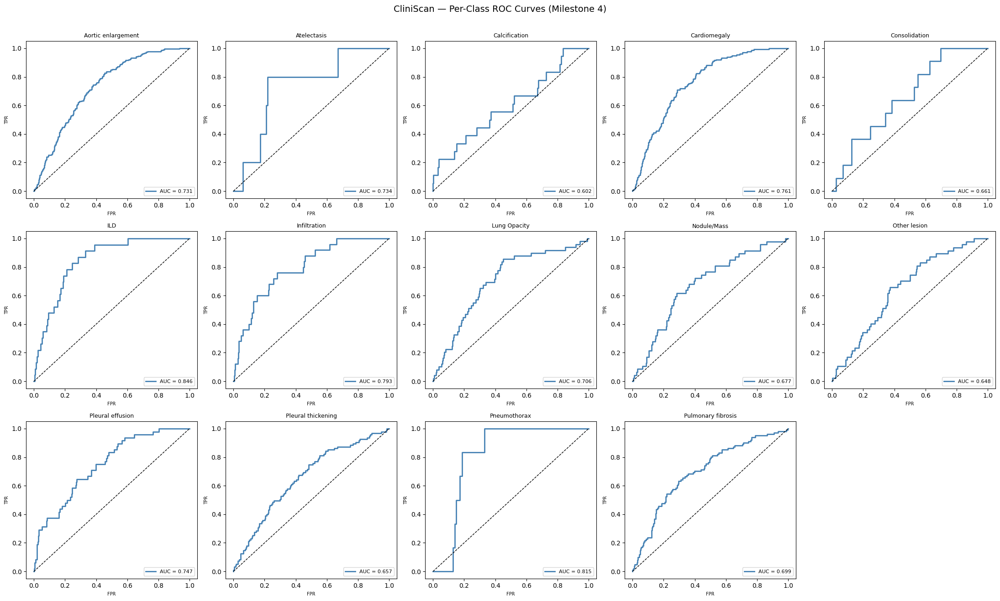

Saved to /kaggle/working/milestone4_outputs/roc_curves.png


In [ ]:
fig, axes = plt.subplots(3, 5, figsize=(22, 13))
axes = axes.flatten()

for i in range(NUM_CLASSES):
    ax      = axes[i]
    y_bin   = (all_labels == i).astype(int)
    y_score = all_probs[:, i]
    try:
        fpr, tpr, _ = roc_curve(y_bin, y_score)
        auc_val     = roc_auc_score(y_bin, y_score)
        ax.plot(fpr, tpr, color='steelblue', lw=2,
                label=f'AUC = {auc_val:.3f}')
        ax.plot([0, 1], [0, 1], 'k--', lw=1)
        ax.legend(loc='lower right', fontsize=8)
    except ValueError:
        ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
    ax.set_title(CLASS_NAMES[i], fontsize=9)
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)

axes[-1].set_visible(False)
plt.suptitle('CliniScan — Per-Class ROC Curves (Milestone 4)', fontsize=14, y=1.01)
plt.tight_layout()
roc_path = os.path.join(M4_DIR, 'roc_curves.png')
plt.savefig(roc_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {roc_path}')

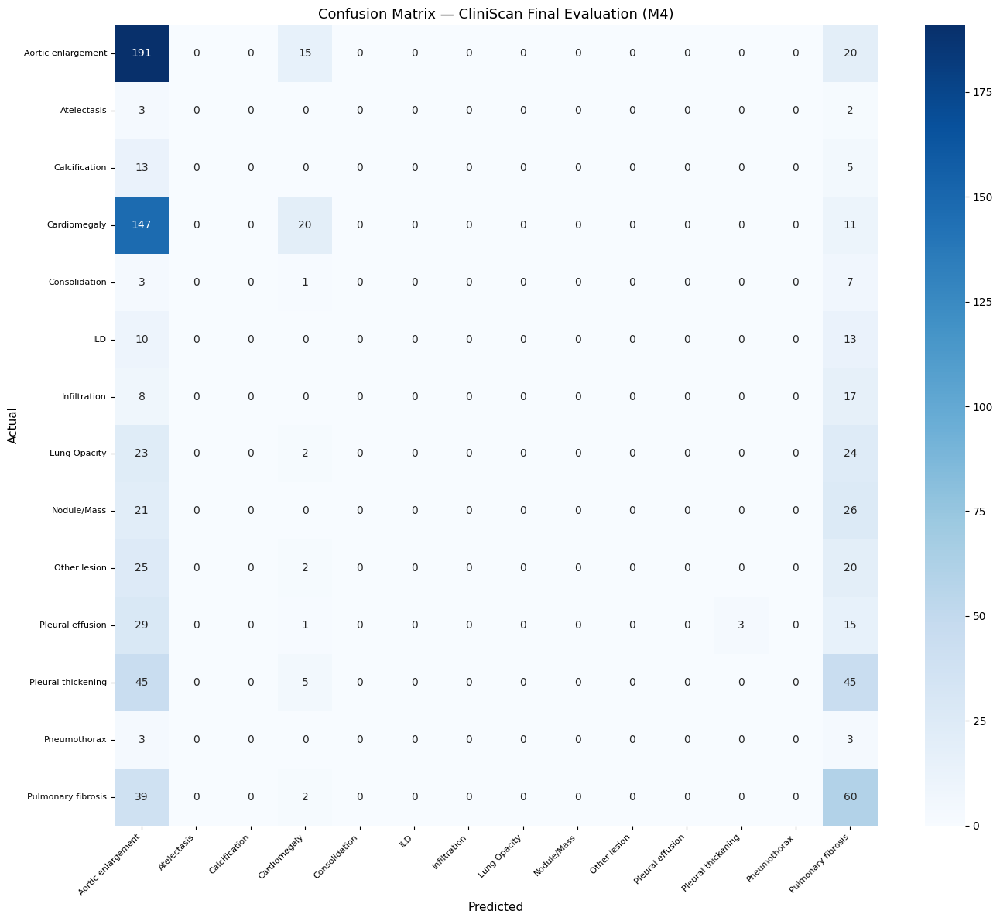

Saved to /kaggle/working/milestone4_outputs/confusion_matrix.png


In [ ]:
cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)]
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual',    fontsize=11)
ax.set_title('Confusion Matrix — CliniScan Final Evaluation (M4)', fontsize=13)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0,  fontsize=8)
plt.tight_layout()
cm_path = os.path.join(M4_DIR, 'confusion_matrix.png')
plt.savefig(cm_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {cm_path}')

In [ ]:
class GradCAM:
    """Gradient-weighted Class Activation Mapping — same implementation as M3."""

    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(
            lambda m, i, o: setattr(self, 'activations', o.detach()))
        target_layer.register_full_backward_hook(
            lambda m, gi, go: setattr(self, 'gradients', go[0].detach()))

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(1).item()
        self.model.zero_grad()
        output[0, class_idx].backward()
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam     = F.relu((weights * self.activations).sum(1, keepdim=True))
        cam     = F.interpolate(cam, size=input_tensor.shape[2:],
                                mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        if cam.max() > cam.min():
            cam = (cam - cam.min()) / (cam.max() - cam.min())
        return cam, class_idx


grad_cam = GradCAM(clf_model, clf_model.layer4[-1])
print('GradCAM hooked on clf_model.layer4[-1]')

GradCAM hooked on clf_model.layer4[-1]


Grad-CAM: 100%|██████████| 8/8 [00:00<00:00, 12.72it/s]


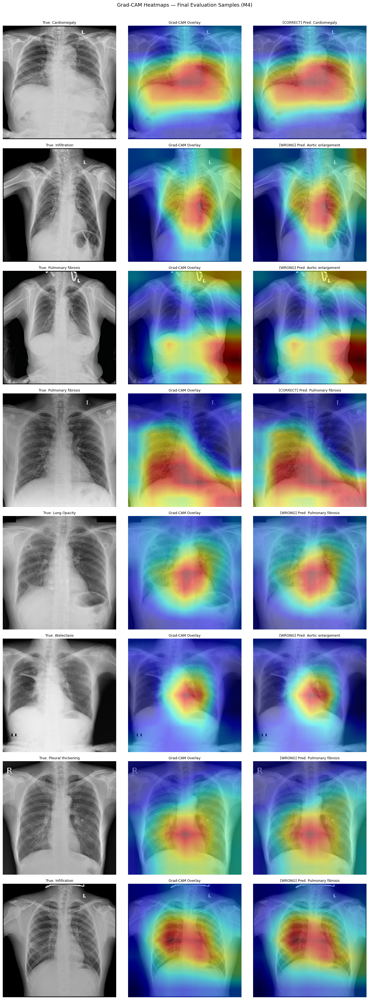

Saved to /kaggle/working/milestone4_outputs/gradcam_gallery_m4.png


In [ ]:
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0) * std + mean
    return np.clip(img, 0, 1)


NUM_GRADCAM = 8
sample_idx  = np.random.choice(len(val_dataset), NUM_GRADCAM, replace=False)

fig, axes = plt.subplots(NUM_GRADCAM, 3, figsize=(14, 4.5 * NUM_GRADCAM))
fig.suptitle('Grad-CAM Heatmaps — Final Evaluation Samples (M4)',
             fontsize=13, y=1.005)

for row, idx in enumerate(tqdm(sample_idx, desc='Grad-CAM')):
    img_t, true_label = val_dataset[idx]
    inp = img_t.unsqueeze(0).to(device)

    cam, pred_label = grad_cam.generate(inp)

    orig  = denormalize(img_t)
    hm    = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    hm    = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
    blend = np.clip(0.55 * orig + 0.45 * hm, 0, 1)

    correct_mark = 'CORRECT' if pred_label == true_label else 'WRONG'

    axes[row, 0].imshow(orig)
    axes[row, 0].set_title(f'True: {CLASS_NAMES[true_label]}', fontsize=9)
    axes[row, 0].axis('off')

    axes[row, 1].imshow(orig)
    axes[row, 1].imshow(cam, cmap='jet', alpha=0.5)
    axes[row, 1].set_title('Grad-CAM Overlay', fontsize=9)
    axes[row, 1].axis('off')

    axes[row, 2].imshow(blend)
    axes[row, 2].set_title(
        f'[{correct_mark}] Pred: {CLASS_NAMES[pred_label]}', fontsize=9)
    axes[row, 2].axis('off')

plt.tight_layout()
cam_path = os.path.join(M4_DIR, 'gradcam_gallery_m4.png')
plt.savefig(cam_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {cam_path}')

In [ ]:
yolo_best = YOLO(BEST_YOLO_PATH)

# Run val on the same YAML as M3
metrics = yolo_best.val(
    data     = YAML_PATH,
    imgsz    = 640,
    conf     = 0.25,
    iou      = 0.5,
    device   = 0 if torch.cuda.is_available() else 'cpu',
    project  = M4_DIR,
    name     = 'yolo_final_eval',
    exist_ok = True,
    save_json= True,
)

print()
print('=' * 50)
print('  CliniScan — Final Detection Results (M4)')
print('=' * 50)
print(f'  mAP@0.50      : {metrics.box.map50:.4f}')
print(f'  mAP@0.50:0.95 : {metrics.box.map:.4f}')
print(f'  Precision     : {metrics.box.mp:.4f}')
print(f'  Recall        : {metrics.box.mr:.4f}')
print('=' * 50)

Ultralytics 8.4.36 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,418,218 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2459.5±553.7 MB/s, size: 416.0 KB)
val: Scanning /kaggle/working/yolo_dataset_m3/labels/val.cache... 879 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 879/879 167.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 55/55 3.0it/s 18.1s0.3s
                   all        879       7227      0.695      0.166      0.434      0.251
    Aortic enlargement        597       1415      0.831      0.397      0.632      0.432
           Atelectasis         35         49      0.667     0.0816      0.385      0.241
         Calcification         97        204      0.464     0.0637      0.261      0.142
          Cardiomegaly        445       1040      0.889      0.387      0.652      0.482
         Consolidation    

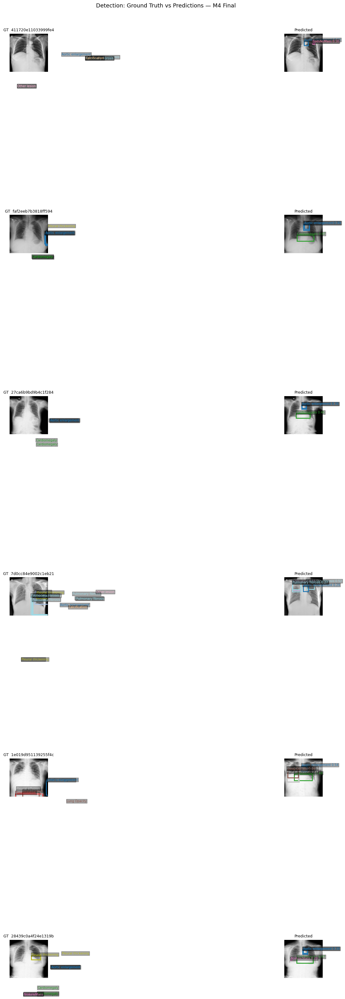

Saved to /kaggle/working/milestone4_outputs/detection_gt_vs_pred_m4.png


In [ ]:
COLORS = plt.cm.get_cmap('tab20', NUM_CLASSES)

def draw_boxes(ax, boxes, labels, title, scores=None):
    for i, (box, lbl) in enumerate(zip(boxes, labels)):
        x1, y1, x2, y2 = box
        color = COLORS(int(lbl))[:3]
        rect  = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor=color, facecolor='none'
        )
        ax.add_patch(rect)
        text = CLASS_NAMES[int(lbl)]
        if scores is not None:
            text += f' {scores[i]:.2f}'
        ax.text(x1, y1 - 4, text, color=color, fontsize=7,
                bbox=dict(facecolor='black', alpha=0.35, pad=1))
    ax.set_title(title, fontsize=9)
    ax.axis('off')


df_bbox  = pd.read_csv(TRAIN_CSV)
df_bbox  = df_bbox[df_bbox['class_id'] != 14]
df_bbox  = df_bbox.dropna(subset=['x_min', 'y_min', 'x_max', 'y_max'])
val_ids  = list(val_df['image_id'].unique())
sample_ids = val_ids[:6]

fig, axes = plt.subplots(len(sample_ids), 2,
                         figsize=(14, 5.5 * len(sample_ids)))
fig.suptitle('Detection: Ground Truth vs Predictions — M4 Final',
             fontsize=13, y=1.01)

for row_i, img_id in enumerate(sample_ids):
    img_path = os.path.join(IMG_DIR, img_id + '.png')
    img      = np.array(Image.open(img_path).convert('RGB'))

    gt       = df_bbox[df_bbox['image_id'] == img_id]
    gt_boxes = gt[['x_min', 'y_min', 'x_max', 'y_max']].values.tolist()
    gt_lbls  = gt['class_id'].values.tolist()

    result   = yolo_best.predict(img_path, conf=0.25, verbose=False)[0]
    pd_boxes = result.boxes.xyxy.cpu().numpy().tolist()
    pd_lbls  = result.boxes.cls.cpu().numpy().tolist()
    pd_conf  = result.boxes.conf.cpu().numpy().tolist()

    axes[row_i, 0].imshow(img)
    draw_boxes(axes[row_i, 0], gt_boxes, gt_lbls, f'GT  {img_id[:18]}')
    axes[row_i, 1].imshow(img)
    draw_boxes(axes[row_i, 1], pd_boxes, pd_lbls, 'Predicted', scores=pd_conf)

plt.tight_layout()
det_path = os.path.join(M4_DIR, 'detection_gt_vs_pred_m4.png')
plt.savefig(det_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved to {det_path}')

In [ ]:
import gradio as gr

# Inference transform — no augmentation
infer_transform = A.Compose([
    A.Resize(IMGSIZE, IMGSIZE),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std =(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

clf_model.eval().to(device)
grad_cam_serve = GradCAM(clf_model, clf_model.layer4[-1])


def cliniscan_predict(pil_image):
    """Full CliniScan inference pipeline for one uploaded X-ray."""

    # 1. Pre-process
    img_np = np.array(pil_image.convert('RGB'))
    tensor = infer_transform(image=img_np)['image']
    inp    = tensor.unsqueeze(0).to(device)

    # 2. Classification
    with torch.no_grad():
        probs = F.softmax(clf_model(inp), dim=1).squeeze().cpu().numpy()
    sorted_idx = np.argsort(probs)[::-1]
    label_dict = {CLASS_NAMES[i]: float(round(probs[i], 4)) for i in sorted_idx}

    # 3. Grad-CAM
    cam, top_cls = grad_cam_serve.generate(inp, class_idx=int(sorted_idx[0]))
    orig_r       = cv2.resize(img_np, (IMGSIZE, IMGSIZE)).astype(np.float32) / 255.0
    hm           = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    hm           = cv2.cvtColor(hm, cv2.COLOR_BGR2RGB) / 255.0
    blend        = np.clip(0.55 * orig_r + 0.45 * hm, 0, 1)
    cam_pil      = Image.fromarray((blend * 255).astype(np.uint8))

    # 4. YOLO detection
    tmp_path = '/tmp/cliniscan_upload.png'
    pil_image.save(tmp_path)
    det_result = yolo_best.predict(tmp_path, conf=0.25, verbose=False)[0]
    det_img    = img_np.copy()
    for box in det_result.boxes:
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].cpu().numpy()]
        cls_idx         = int(box.cls.item())
        conf            = float(box.conf.item())
        color           = (57, 255, 20)
        cv2.rectangle(det_img, (x1, y1), (x2, y2), color, 2)
        cv2.putText(
            det_img, f'{CLASS_NAMES[cls_idx]} {conf:.2f}',
            (x1, max(y1 - 5, 12)),
            cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1
        )
    det_pil = Image.fromarray(det_img)

    return label_dict, cam_pil, det_pil


# Build Gradio UI
with gr.Blocks(title='CliniScan') as demo:
    gr.Markdown("""
    # CliniScan - Lung Abnormality Detection
    ### Milestone 4 Deployment Demo
    Upload a chest X-ray to get classification probabilities,
    a Grad-CAM heatmap, and YOLOv11s detection boxes.
    """)

    with gr.Row():
        inp_img = gr.Image(type='pil', label='Upload Chest X-ray (PNG / JPEG)')

    run_btn = gr.Button('Analyse X-ray', variant='primary')

    with gr.Row():
        out_label = gr.Label(num_top_classes=5, label='Top-5 Predicted Findings')

    with gr.Row():
        out_cam = gr.Image(label='Grad-CAM Heatmap (Top Prediction)')
        out_det = gr.Image(label='YOLOv11s Detection Output')

    gr.Markdown("""
    ---
    Disclaimer: This tool is for research / educational purposes only.
    It is NOT a substitute for professional radiological assessment.
    """)

    run_btn.click(
        fn      = cliniscan_predict,
        inputs  = [inp_img],
        outputs = [out_label, out_cam, out_det]
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://79b84ce7d26c383522.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
